# Turnover Normalizing Flow

Train a normalizing flow to predict turnover destinations conditioned on thrower position (no player).

Training data: drops (type 20) and throwaways (type 22).
All coordinates normalized so every throw attacks toward Y=110.

In [13]:
import psycopg2
from psycopg2.extras import RealDictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from nflows import flows, distributions, transforms

import joblib, os

np.random.seed(42)
torch.manual_seed(42)

DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': 'joemolder',
    'password': '',
    'host': 'localhost',
    'port': 5432
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)

## 1. Load Turnover Data

Two turnover types, all direction-normalized (away team coords flipped):
- **Drops** (type 20): thrower position → receiver position
- **Throwaways** (type 22): thrower position → turnover position

In [14]:
conn = get_db_connection()
cur = conn.cursor()

# Drops and throwaways with direction normalization
cur.execute("""
    SELECT
        CASE WHEN e.team = g.away_team_id THEN -e.thrower_x ELSE e.thrower_x END as thrower_x,
        CASE WHEN e.team = g.away_team_id THEN 120 - e.thrower_y ELSE e.thrower_y END as thrower_y,
        CASE WHEN e.team = g.away_team_id THEN
            CASE WHEN e.event_type = 20 THEN -e.receiver_x ELSE -e.turnover_x END
        ELSE
            CASE WHEN e.event_type = 20 THEN e.receiver_x ELSE e.turnover_x END
        END as dest_x,
        CASE WHEN e.team = g.away_team_id THEN
            CASE WHEN e.event_type = 20 THEN 120 - e.receiver_y ELSE 120 - e.turnover_y END
        ELSE
            CASE WHEN e.event_type = 20 THEN e.receiver_y ELSE e.turnover_y END
        END as dest_y,
        e.event_type
    FROM events e
    JOIN games g ON e.game_id = g.game_id
    WHERE e.event_type IN (20, 22)
        AND e.thrower_x IS NOT NULL AND e.thrower_y IS NOT NULL
        AND (
            (e.event_type = 20 AND e.receiver_x IS NOT NULL AND e.receiver_y IS NOT NULL)
            OR (e.event_type = 22 AND e.turnover_x IS NOT NULL AND e.turnover_y IS NOT NULL)
        )
""")
rows = cur.fetchall()

cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f"Total turnover events: {len(df):,}")
print(f"  Drops (20): {(df.event_type == 20).sum():,}")
print(f"  Throwaways (22): {(df.event_type == 22).sum():,}")

Total turnover events: 28,217
  Drops (20): 4,212
  Throwaways (22): 24,005


In [15]:
# Drop rows with NaN destinations
df = df.dropna(subset=['dest_x', 'dest_y', 'thrower_x', 'thrower_y'])
print(f"After dropping NaNs: {len(df):,}")

# Normalize coordinates to [0, 1]
df['thrower_x_norm'] = (df['thrower_x'] + 25) / 50
df['thrower_y_norm'] = df['thrower_y'] / 120
df['dest_x_norm'] = (df['dest_x'] + 25) / 50
df['dest_y_norm'] = df['dest_y'] / 120

# Context: [thrower_x_norm, thrower_y_norm]  (no player)
context = df[['thrower_x_norm', 'thrower_y_norm']].values.astype(np.float32)
target = df[['dest_x_norm', 'dest_y_norm']].values.astype(np.float32)

print(f"Context shape: {context.shape}")
print(f"Target shape: {target.shape}")

After dropping NaNs: 28,217
Context shape: (28217, 2)
Target shape: (28217, 2)


In [16]:
# Train/test split
context_train, context_test, target_train, target_test = train_test_split(
    context, target, test_size=0.2, random_state=42
)

print(f"Train: {len(context_train):,}")
print(f"Test: {len(context_test):,}")

Train: 22,573
Test: 5,644


## 2. Model Architecture

Same flow structure as the throw model but with a simpler context network (no player embedding).

In [17]:
class TurnoverContextNetwork(nn.Module):
    """Processes thrower position context (no player embedding)."""
    def __init__(self, hidden_dim=64, output_dim=32):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, context):
        return self.network(context)


def create_turnover_flow(num_layers=5, hidden_features=128, context_features=32):
    base_dist = distributions.StandardNormal(shape=[2])
    context_net = TurnoverContextNetwork(hidden_dim=64, output_dim=context_features)

    transform_list = []
    for _ in range(num_layers):
        transform_list.append(
            transforms.MaskedAffineAutoregressiveTransform(
                features=2,
                hidden_features=hidden_features,
                context_features=context_features,
                num_blocks=2,
            )
        )
        transform_list.append(transforms.ReversePermutation(features=2))

    transform = transforms.CompositeTransform(transform_list)
    flow = flows.Flow(transform, base_dist)
    return flow, context_net

In [18]:
# Hyperparameters
NUM_LAYERS = 5
HIDDEN_FEATURES = 128
CONTEXT_FEATURES = 32
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.0001
BATCH_SIZE = 256
EPOCHS = 200

flow, context_net = create_turnover_flow(
    num_layers=NUM_LAYERS,
    hidden_features=HIDDEN_FEATURES,
    context_features=CONTEXT_FEATURES,
)

flow_params = sum(p.numel() for p in flow.parameters())
context_params = sum(p.numel() for p in context_net.parameters())
print(f"Flow params: {flow_params:,}")
print(f"Context params: {context_params:,}")
print(f"Total: {flow_params + context_params:,}")

Flow params: 398,100
Context params: 6,432
Total: 404,532


In [19]:
# Data loaders
train_dataset = TensorDataset(torch.FloatTensor(context_train), torch.FloatTensor(target_train))
test_dataset = TensorDataset(torch.FloatTensor(context_test), torch.FloatTensor(target_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Optimizer + scheduler
optimizer = optim.Adam(
    list(flow.parameters()) + list(context_net.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=10, min_lr=1e-6)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 89
Test batches: 23


## 3. Training

In [20]:
def train_epoch(flow, context_net, loader, optimizer):
    flow.train()
    context_net.train()
    total_loss = 0
    for batch_ctx, batch_tgt in loader:
        optimizer.zero_grad()
        ctx_features = context_net(batch_ctx)
        log_prob = flow.log_prob(batch_tgt, context=ctx_features)
        loss = -log_prob.mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(flow.parameters()) + list(context_net.parameters()), max_norm=5.0
        )
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(flow, context_net, loader):
    flow.eval()
    context_net.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_ctx, batch_tgt in loader:
            ctx_features = context_net(batch_ctx)
            log_prob = flow.log_prob(batch_tgt, context=ctx_features)
            loss = -log_prob.mean()
            total_loss += loss.item()
    return total_loss / len(loader)

In [21]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print('-' * 50)

for epoch in range(EPOCHS):
    train_loss = train_epoch(flow, context_net, train_loader, optimizer)
    val_loss = validate(flow, context_net, test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_flow_state = flow.state_dict().copy()
        best_context_state = context_net.state_dict().copy()
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:6d} | {train_loss:12.4f} | {val_loss:12.4f} | {lr:10.6f}")

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        flow.load_state_dict(best_flow_state)
        context_net.load_state_dict(best_context_state)
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
    10 |      -0.6102 |      -0.5780 |   0.000500
    20 |      -0.6425 |      -0.6034 |   0.000500
    30 |      -0.6445 |      -0.6531 |   0.000500
    40 |      -0.6607 |      -0.6142 |   0.000500
    50 |      -0.6719 |      -0.6554 |   0.000350
    60 |      -0.6796 |      -0.6595 |   0.000245
    70 |      -0.6890 |      -0.6713 |   0.000245
    80 |      -0.6991 |      -0.6747 |   0.000171
    90 |      -0.6996 |      -0.6614 |   0.000171
   100 |      -0.7075 |      -0.6777 |   0.000120

Early stopping at epoch 101

Best validation loss: -0.6782


## 4. Training Curve

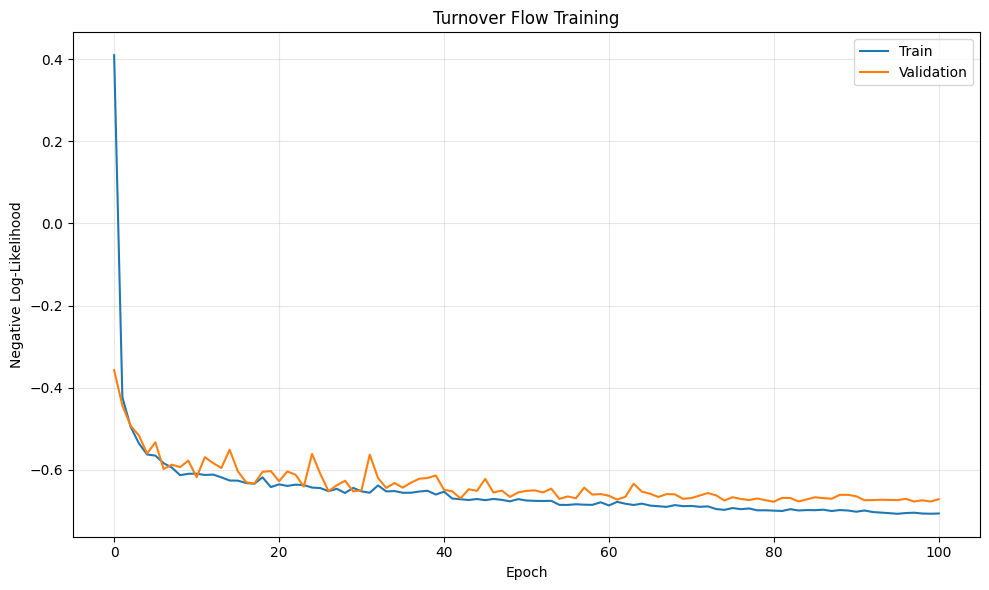

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('Turnover Flow Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('turnover_flow_training_curve.png', dpi=150)
plt.show()

## 5. Quick Visualization

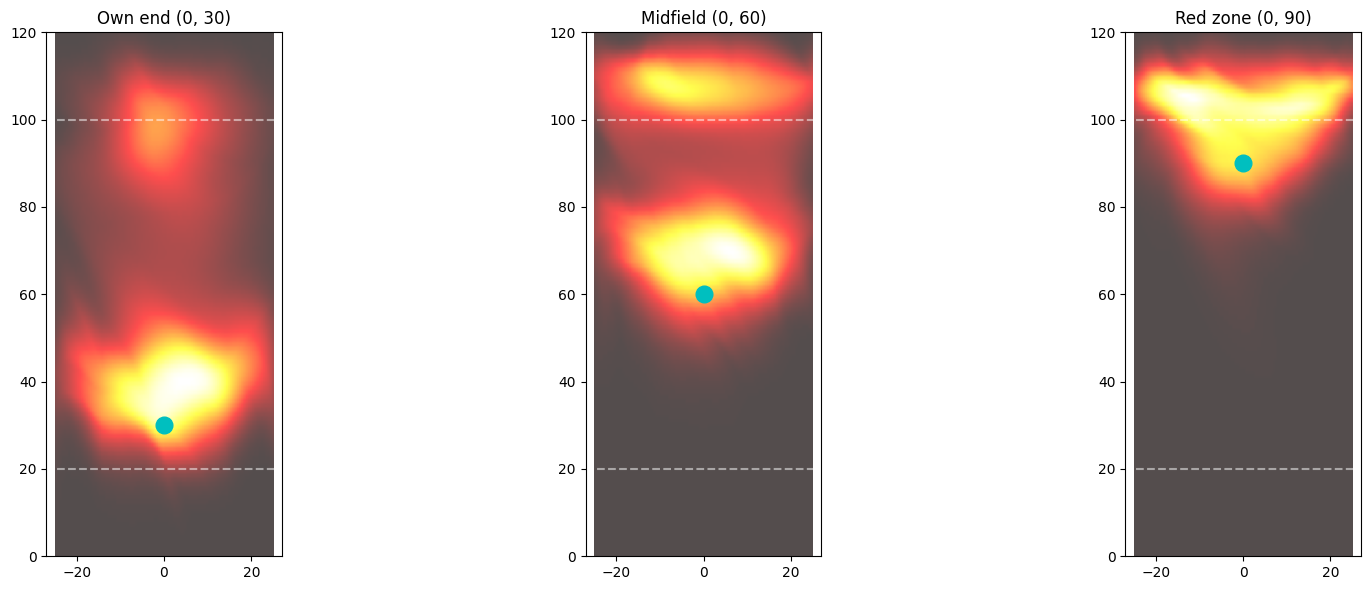

In [23]:
def predict_turnover_distribution(flow, context_net, thrower_x, thrower_y, grid_size=100):
    flow.eval()
    context_net.eval()
    x_norm = (thrower_x + 25) / 50
    y_norm = thrower_y / 120
    ctx = torch.FloatTensor([[x_norm, y_norm]])

    with torch.no_grad():
        ctx_features = context_net(ctx)
        x_bins = np.linspace(0, 1, grid_size)
        y_bins = np.linspace(0, 1, int(grid_size * 1.2))
        xx, yy = np.meshgrid(x_bins, y_bins)
        grid_points = torch.FloatTensor(np.stack([xx.ravel(), yy.ravel()], axis=1))
        ctx_expanded = ctx_features.expand(grid_points.shape[0], -1)
        log_probs = flow.log_prob(grid_points, context=ctx_expanded)
        probs = torch.exp(log_probs).numpy()
        grid = probs.reshape(len(y_bins), len(x_bins))
    return grid


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
positions = [(0, 30, 'Own end'), (0, 60, 'Midfield'), (0, 90, 'Red zone')]

for ax, (tx, ty, label) in zip(axes, positions):
    grid = predict_turnover_distribution(flow, context_net, tx, ty)
    ax.imshow(grid, extent=[-25, 25, 0, 120], origin='lower', cmap='hot', alpha=0.7)
    ax.plot(tx, ty, 'co', markersize=12)
    ax.axhline(y=20, color='white', linestyle='--', alpha=0.5)
    ax.axhline(y=100, color='white', linestyle='--', alpha=0.5)
    ax.set_title(f'{label} ({tx}, {ty})')
    ax.set_xlim(-27, 27)
    ax.set_ylim(0, 120)

plt.tight_layout()
plt.show()

## 6. Save Model

In [24]:
os.makedirs('models', exist_ok=True)

save_dict = {
    'flow_state_dict': flow.state_dict(),
    'context_net_state_dict': context_net.state_dict(),
    'hyperparameters': {
        'num_layers': NUM_LAYERS,
        'hidden_features': HIDDEN_FEATURES,
        'context_features': CONTEXT_FEATURES,
    },
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
}

joblib.dump(save_dict, 'models/turnover_flow_model.pkl')
print('Saved to models/turnover_flow_model.pkl')

Saved to models/turnover_flow_model.pkl
